In [16]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
import re
warnings.filterwarnings('ignore')
pd.options.plotting.backend = "plotly"

In [134]:
# df = pd.read_csv('data/filtered_watches.csv')
# df = df[~df['Watch_Mark'].isin(['126610LN', '16610', '116613LN', '116610LN', '16613', '5513', '124060'])]
# df['quantity'] = df.groupby('Watch_Mark')['Watch_Mark'].transform('size')
# df[df['quantity'] >= 30000.0]
# df["quantity"].max()v

,Watch_Name,Price,Datetime,Watch_Mark,quantity
128,Rolex Submariner Date,20500.0,2024-03-29 17:00:00,116610LV,32462.0
204,Rolex Submariner Date,17999.0,2024-03-29 17:00:00,126613lb,34792.0
209,Rolex Submariner Date,19900.0,2024-03-29 17:00:00,116610LV,32462.0
245,Rolex Submariner (No Date),11250.0,2024-03-29 17:00:00,114060,38093.0
248,Rolex Submariner Date,18800.0,2024-03-29 17:00:00,126613lb,34792.0
...,...,...,...,...,...
2782696,Rolex Submariner Date,17980.0,2024-04-27 23:39:12,126610lv,43720.0
2782727,Rolex Submariner Date,17000.0,2024-04-27 23:39:12,126610lv,43720.0
2782759,Rolex Submariner Date,17980.0,2024-04-27 23:39:12,126610lv,43720.0
2782822,Rolex Submariner Date,17980.0,2024-04-27 23:39:12,126610lv,43720.0


In [8]:
df = pd.read_csv('data/filtered_watches.csv')
df['quantity'] = df.groupby(['Watch_Mark', 'Datetime'])['Watch_Mark'].transform('size')
df

,Watch_Name,Price,Datetime,Watch_Mark,quantity
0,Rolex Submariner Date,18225.0,2024-03-29 17:00:00,Blue Dial 41mm Two Tone 126613LB Unworn 2023,2.0
1,Rolex Submariner (No Date),12415.0,2024-03-29 17:00:00,41mm 124060 Unworn 2023,2.0
2,Rolex Submariner Date,19150.0,2024-03-29 17:00:00,126613LB NEW 2024 MARCH Blue Gold Steel 41 mm,2.0
3,Rolex Submariner Date,10574.0,2024-03-29 17:00:00,116613LN,51.0
4,Rolex Submariner Date,13795.0,2024-03-29 17:00:00,In Stock Submariner Date Black Dial 126610LN O...,1.0
...,...,...,...,...,...
2782911,Rolex Submariner Date,13999.0,2024-04-27 23:39:12,126610LN,109.0
2782912,Rolex Submariner (No Date),9595.0,2024-04-27 23:39:12,In Stock Holes Case Submariner No Date Black D...,7.0
2782913,Rolex Submariner Date,14290.0,2024-04-27 23:39:12,41mm NEW/UNWORN,7.0
2782914,Rolex Submariner Date,13385.0,2024-04-27 23:39:12,Ceramic 41mm Black Dial 126610LN Box & Papers ...,7.0


In [136]:
# keywords = {
#     'colors': ["black", "white", "red", "blue", "green", "yellow", "orange", "purple", "gold", "silver",
#                "gray", "brown", "pink", "lime", "teal", "olive",
#                "mint", "indigo", "violet", "tan", "cream", "sapphire", "bluesy", "chocolate", "grey"],
#     'materials': ['oystersteel', 'yellow gold', 'white gold', 'everose gold', 'steel', 'stainless', 'gold', 'ceramic',
#                   'tropical dial', 'blue dial', 'sapphire', 'luminous', 'diamonds', 'leather', 'rubber'],
#     'editions': ['kermit', 'hulk', 'cermit', 'serti', 'smurf', 'starbucks',
#                  'two-tone', '50th anniversary submariner',
#                  'oyster perpetual', 'ghost bezel',
#                  'maxi dial', 'transitional', 'military', 'comex'],
#     'bezels': ['aluminum bezel', 'cerachrom bezel', 'ceramic bezel', 'blue ceramic bezel', 'black ceramic bezel',
#                'diamond bezel', 'green bezel', 'mkii bezel', 'mk1 bezel'],
#     'sizes': ['40mm', '41mm', '37mm', '36mm', '39mm']  # Normalized space
# }

# def count_keywords(watch_mark, keywords):
#     watch_mark_str = str(watch_mark).lower()  # Convert to string and lowercase for uniform comparison
#     count = 0  # Initialize a count variable
#     keyword_patterns = {category: [re.compile(r'\b' + re.escape(keyword) + r'\b') for keyword in set(keyword_list)]
#                         for category, keyword_list in keywords.items()}
#     for category, patterns in keyword_patterns.items():
#         for pattern in patterns:
#             count += len(pattern.findall(watch_mark_str))  # Increment count by the number of occurrences found
#     return count if count > 0 else 0  # Return the total count, default to 0 if no keywords found

# # Count keyword occurrences for each row in 'Watch_Mark' and assign to 'quantity'
# df['quantity'] = df['Watch_Mark'].apply(lambda x: count_keywords(x, keywords))

# # Display the DataFrame with the adjustments
# df.head()


,Watch_Name,Price,Datetime,Watch_Mark,quantity
0,Rolex Submariner Date,18225.0,2024-03-29 17:00:00,Blue Dial 41mm Two Tone 126613LB Unworn 2023,3
1,Rolex Submariner (No Date),12415.0,2024-03-29 17:00:00,41mm 124060 Unworn 2023,1
2,Rolex Submariner Date,19150.0,2024-03-29 17:00:00,126613LB NEW 2024 MARCH Blue Gold Steel 41 mm,4
3,Rolex Submariner Date,10574.0,2024-03-29 17:00:00,116613LN,0
4,Rolex Submariner Date,13795.0,2024-03-29 17:00:00,In Stock Submariner Date Black Dial 126610LN O...,1


In [64]:
# def agg_hist_data(df: pd.DataFrame) -> pd.DataFrame:
#     """
#     Group the dataframe by 'market', 'market_hash_name', and 'dates.date'.
#     Sums the 'quantity' and takes the minimum of 'price'.

#     Parameters:
#         df (pd.DataFrame): The input DataFrame.

#     Returns:
    
#         pd.DataFrame: The aggregated DataFrame.
#     """
#     return df.groupby(['Watch_Name', 'Watch_Mark', 'Datetime']).agg({
#         'quantity': 'sum',
#         'Price': 'min'
#     }).reset_index()


# agg_df = agg_hist_data(df)

# agg_df.head()

def agg_hist_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Group the dataframe by 'market', 'market_hash_name', and 'dates.date'.
    Sums the 'quantity' and takes the minimum of 'price'.

    Parameters:
        df (pd.DataFrame): The input DataFrame.

    Returns:
    
        pd.DataFrame: The aggregated DataFrame.
    """
    tmp_df =  df.groupby(['Watch_Name', 'Watch_Mark', 'Datetime']).agg({
        'quantity': 'sum',
        'Price': 'min',
    }).reset_index()
    tmp_df = tmp_df[tmp_df["quantity"] > 0]

    return tmp_df


def fluctuation_data(df: pd.DataFrame) -> pd.DataFrame:

    fluctuation = df.groupby(['Watch_Name', 'Watch_Mark']).agg({
    'quantity': ['std', 'mean', 'min', 'max',
                 lambda x: x.quantile(0.10),
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.50),
                 lambda x: x.quantile(0.75),
                 lambda x: x.quantile(0.90)]
    }).reset_index()

    fluctuation = fluctuation[fluctuation[("quantity", "mean")] > 0]
    
    # Renaming columns
    fluctuation.columns = [
        'Watch_Name',
        'Watch_Mark',
        'std_quantity',
        'mean_quantity',
        'min_quantity',
        'max_quantity',
        '10th_percentile_quantity',
        '25th_percentile_quantity',
        'median',
        '75th_percentile_quantity',
        '90th_percentile_quantity',
    ]
    
    # Calculating coefficient of variation
    fluctuation['coef_of_variation'] = fluctuation['std_quantity'] / fluctuation['mean_quantity']
    
    return fluctuation
        

agg_df = agg_hist_data(df)
fluctuation = fluctuation_data(agg_df)
fluctuation

,Watch_Name,Watch_Mark,std_quantity,mean_quantity,min_quantity,max_quantity,10th_percentile_quantity,25th_percentile_quantity,median,75th_percentile_quantity,90th_percentile_quantity,coef_of_variation
0,Rolex Submariner,114060 Full Set,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
1,Rolex Submariner,11660LN,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
2,Rolex Submariner,116613 18k/ss 40mm Blue Ceramic Divery,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
3,Rolex Submariner,116613LB Two Tone 40mm Blue Dial Ceramic B&P 2010,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
4,Rolex Submariner,116613lb 2018 Card 18k Two-tone Blue Automatic...,0.173785,1.010067,1.0,4.0,1.0,1.0,1.0,1.0,1.0,0.172053
...,...,...,...,...,...,...,...,...,...,...,...,...
7406,Rolex Submariner Date,ー blue 16613,1.340782,1.818182,1.0,4.0,1.0,1.0,1.0,4.0,4.0,0.737430
7407,Rolex Submariner Date,ー green 116610LV,1.507874,2.500000,1.0,4.0,1.0,1.0,2.5,4.0,4.0,0.603150
7408,Rolex Submariner Date,中古 Sランク ROLEX ロレックス サブマリーナー デイト 腕時計 ブラック文字盤 12...,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000
7409,Rolex Submariner Date,新品 ロレックス サブマリーナーデイト 126613LB SSxYG 自動巻,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000


In [10]:
# fluctuation = agg_df.groupby(['Watch_Name', 'Watch_Mark']).agg({
#     'quantity': ['std', 'mean', 'min', 'max',
#                  lambda x: x.quantile(0.10),
#                  lambda x: x.quantile(0.25),
#                  lambda x: x.quantile(0.50),
#                  lambda x: x.quantile(0.75),
#                  lambda x: x.quantile(0.90)],
#     'Price': ['mean']
# }).reset_index()

# # Renaming columns
# fluctuation.columns = [
#     'Watch_Name',
#     'Watch_Mark',
#     'std_quantity',
#     'mean_quantity',
#     'min_quantity',
#     'max_quantity',
#     '10th_percentile_quantity',
#     '25th_percentile_quantity',
#     'median',
#     '75th_percentile_quantity',
#     '90th_percentile_quantity',
#     'mean_price'
# ]

# # Calculating coefficient of variation
# fluctuation['coef_of_variation'] = fluctuation['std_quantity'] / fluctuation['mean_quantity']

# fluctuation.head()

,Watch_Name,Watch_Mark,std_quantity,mean_quantity,min_quantity,max_quantity,10th_percentile_quantity,25th_percentile_quantity,median,75th_percentile_quantity,90th_percentile_quantity,mean_price,coef_of_variation
0,Rolex Submariner,114060 Full Set,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12373.400000,0.000000
1,Rolex Submariner,11660LN,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12903.285714,0.000000
2,Rolex Submariner,116613 18k/ss 40mm Blue Ceramic Divery,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15377.585714,0.000000
3,Rolex Submariner,116613LB Two Tone 40mm Blue Dial Ceramic B&P 2010,0.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,18816.326425,0.000000
4,Rolex Submariner,116613lb 2018 Card 18k Two-tone Blue Automatic...,0.173785,1.010067,1.0,4.0,1.0,1.0,1.0,1.0,1.0,16529.966443,0.172053


In [50]:
agg_df.groupby("Datetime").agg({
    "quantity": lambda x: len(x)
})

,quantity
Datetime,
2024-03-29 17:00:00,5475
2024-03-29 18:00:17,5481
2024-03-29 22:30:05,5479
2024-03-29 23:21:56,5465
2024-03-30 00:13:42,5459
...,...
2024-04-29 13:55:26,5143
2024-04-29 14:54:59,5183
2024-04-29 15:49:26,5405


In [58]:
def construct_index(df):

    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
        
    df['index'] = df['quantity'] * df['Price']
#     df['index'] = df['index'].ewm(span=500, adjust=False).mean()
    index_data = df.groupby('Datetime')['index'].sum().reset_index()

    return index_data

watch_index_data = construct_index(agg_df)


watch_index_data.head(10)

,Datetime,index
0,2024-03-29 17:00:00,3.603985e+09
1,2024-03-29 18:00:17,3.583592e+09
2,2024-03-29 22:30:05,3.518145e+09
3,2024-03-29 23:21:56,3.478821e+09
4,2024-03-30 00:13:42,3.463484e+09
5,2024-03-30 10:05:58,3.527080e+09
6,2024-03-30 10:57:51,3.454044e+09
7,2024-03-30 11:49:43,2.157888e+08
8,2024-03-30 11:49:44,2.215021e+09
9,2024-03-30 12:41:31,3.380415e+09


In [59]:
def plot_indexes(index1, index2, title):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=index1['Datetime'], y=index1['index'], name='Index 1', mode='lines'))

    fig.add_trace(go.Scatter(x=index2['Datetime'], y=index2['index'], name='Index 2', mode='lines'))

    fig.update_layout(
        title=title,
        xaxis_title='dates',
        yaxis_title='index'
    )

    fig.show()

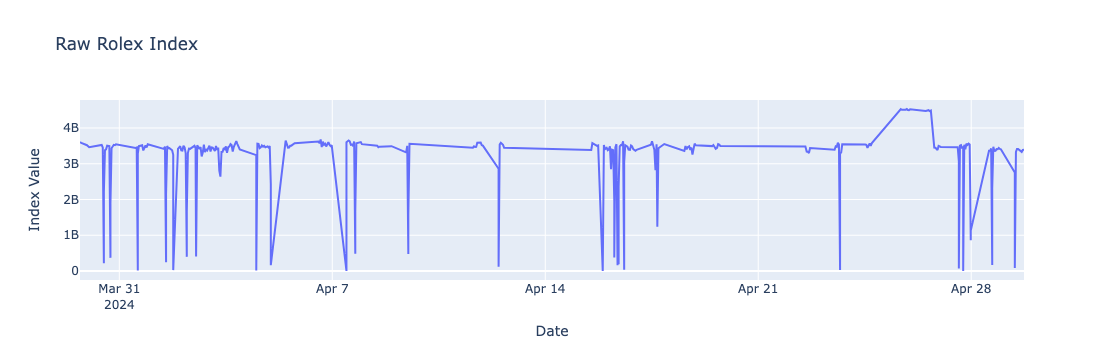

In [60]:
raw_index = construct_index(agg_df)

fig = px.line(raw_index, x='Datetime', y='index', title='Raw Rolex Index')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Index Value')
fig.show()

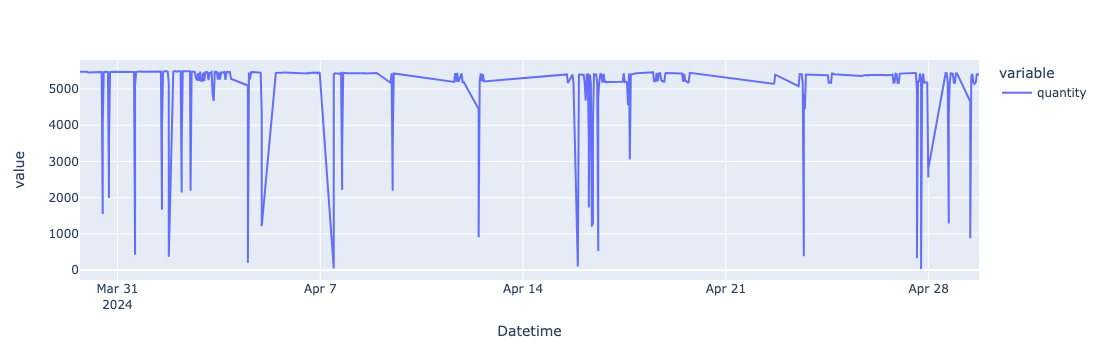

In [61]:
agg_df.groupby("Datetime").agg({
    "quantity": lambda x: len(x)
}).plot()

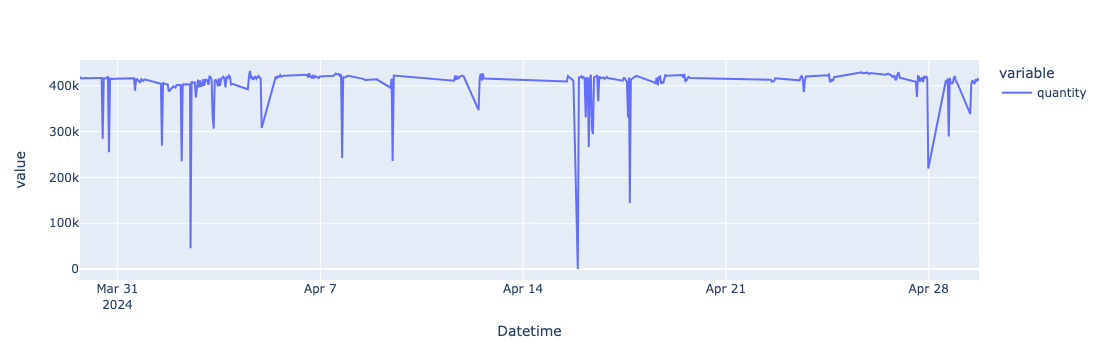

In [62]:
agg_sum = agg_df.groupby(pd.Grouper(key="Datetime", freq="1min")).agg({
    "quantity": "sum"
}).reset_index()

agg_sum = agg_sum[agg_sum["quantity"] > 0]

agg_sum = agg_sum.groupby(pd.Grouper(key="Datetime", freq="2min")).agg({
    "quantity": "sum"
})

agg_sum = agg_sum[agg_sum["quantity"] > 0]

agg_sum.plot()

In [43]:
def most_traded_index(df, n, quantity_measure, raw_index,
                            compare=True, min_quantity=0, plot=True):
    """
    Identifies the most traded watches based on a specified quantity measure and plots their trading index.

    Parameters:
    - df: DataFrame containing watch trading data.
    - n: Number of top traded watches to consider.
    - quantity_measure: The measure of quantity to use for trading volume.
    - raw_index: DataFrame representing the raw index to compare against.
    - compare: Boolean indicating whether to compare the result with the raw index.
    - min_quantity: Minimum quantity threshold for trades to be included.
    - plot: Boolean indicating whether to plot the index.

    Returns:
    - A tuple containing the most traded watches index DataFrame and the filtered DataFrame of most traded watches.
    """

    # Calculate number of unique price points for each watch model and mark
    unique_prices = df.groupby(['Watch_Name', 'Watch_Mark'])['Price'].nunique().reset_index()
    unique_prices = unique_prices.rename(columns={'Price': 'unique_prices'})

    df = df.merge(unique_prices, on=['Watch_Name', 'Watch_Mark'], how='left')
    
    traded_ranking = df[['Watch_Name', 'Watch_Mark', 'unique_prices']]\
        .drop_duplicates()\
        .sort_values('unique_prices', ascending=False)
    
    most_traded = df[['Watch_Name', 'Watch_Mark', 'Datetime', 'Price', quantity_measure]]
    most_traded = most_traded.rename(columns={quantity_measure: 'quantity'})
    top_n_mt = traded_ranking[:n][['Watch_Name', 'Watch_Mark']]
    most_traded = most_traded.merge(top_n_mt, on=['Watch_Name', 'Watch_Mark'])
    most_traded = most_traded[most_traded.quantity >= min_quantity]
    mt_n_index = construct_index(most_traded)  # You will need to update the construct_index function accordingly
    if plot:
        if compare:
            plot_indexes(raw_index, mt_n_index, f'Most traded {n} (min quantity {min_quantity}) vs raw')
        else:
            fig = px.line(mt_n_index, x='Datetime', y='index', title=f'Most traded {n} (min quantity {min_quantity})')
            fig.update_xaxes(title_text='Date')
            fig.update_yaxes(title_text='Index Value')
            fig.show()
    print(f'Number of products: {len(most_traded[["Watch_Name", "Watch_Mark"]].drop_duplicates())}')
    return mt_n_index, most_traded

In [44]:
def simulate_attack(df, item_list, day_count, increase=True):
    # Start from the 20th date in the data. It could be anything.
    date_list = [df['Datetime'][20] + pd.Timedelta(days=i) for i in range(day_count)]
    print(date_list)
    
    # Days and items to target
    condition = ((df['Watch_Mark'].isin(item_list)) & (df['Datetime'].isin(date_list)))
    if increase:
     # Attack makes the index of each item equal to 1 trillion
     df['index'] = np.where(condition, 1e12, df['index'])
    else:
     # Attack makes the index value of the input items 0
     df['index'] = np.where(condition, 0, df['index'])
    return df

In [45]:
def get_avg_share(df):
    # GET INDEX SHARE
    daily_sum = df.groupby('Datetime')['index'].sum().reset_index()
    daily_sum = daily_sum.rename(columns={'index': 'daily_sum_index'})
    df = df.merge(daily_sum, on='Datetime')
    df['index_share'] = (df['index'] / df['daily_sum_index'])
    df = df.drop(columns=['daily_sum_index'])

    half_year_date = df.loc[:, "Datetime"].drop_duplicates().iloc[10,]
    print(half_year_date)
    avg_mapping = df.loc[df['Datetime'] < half_year_date, ['Watch_Name', 'Watch_Mark', 'Datetime', 'index_share']]
    avg_mapping = avg_mapping.groupby(['Watch_Name', 'Watch_Mark'])['index_share'].agg(['mean', 'std']).reset_index()
    avg_mapping = avg_mapping.rename(columns={'mean': 'avg_index_share', 'std': 'std_index_share'})

    # Filter the main dataframe for entries after the half-year date and merge with averages
    df = df[df['Datetime'] > half_year_date]
    df = df.merge(avg_mapping, on=['Watch_Name', 'Watch_Mark'], how='inner')

    return df, avg_mapping

In [46]:
def get_index_share(df):
    # GET INDEX SHARE
    daily_sum = df.groupby('Datetime')['index'].sum().reset_index()
    daily_sum = daily_sum.rename(columns={'index': 'daily_sum_index'})
    df = df.merge(daily_sum, on='Datetime')
    df['index_share'] = (df['index'] / df['daily_sum_index'])
    df = df.drop(columns=['daily_sum_index'])
    return df

In [47]:
def compute_multiplier(mean, k):
    return np.exp(-k * mean)


# k_values = [0.1, 1, 10, 100, 1000]
# mean_values = np.linspace(mapping['avg_index_share'].min(), mapping['avg_index_share'].max(), 1000)
# multiplier_values = {k: compute_multiplier(mean_values, k) for k in k_values}
# plt.figure(figsize=(10, 6))
# for k, multiplier in multiplier_values.items():
#     plt.plot(mean_values, multiplier, label=f'k={k}')
    
# plt.xlabel('avg index share')
# plt.ylabel('mutliplier')
# plt.title('Mutliplier value vs mean index share')
# plt.legend()
# plt.grid(True)
# plt.show()


def get_caps(mapping, upper_multiplier=1, lower_multiplier=1, items=None):
  '''
  Get caps for the index share of each item in the mapping.
  If `items` is not None, then the caps are only applied to the items in the list.
  Else, the caps are applied to all items.
  '''

  if not items:
    mapping['upper_cap_index_share'] = mapping['avg_index_share'] + upper_multiplier*mapping['std_index_share']
    mapping['lower_cap_index_share'] = np.where(mapping['avg_index_share'] - lower_multiplier*mapping['std_index_share'] > 0,
                                              mapping['avg_index_share'] - lower_multiplier*mapping['std_index_share'], 0)
  if items:
    # Apply caps only to the items in the list
    mapping['upper_cap_index_share'] = np.where(
      mapping['Watch_Mark'].isin(items),
      mapping['avg_index_share'] + upper_multiplier*mapping['std_index_share'],
      1
    )
    mapping['lower_cap_index_share'] = np.where(
      mapping['Watch_Mark'].isin(items),
      np.where(mapping['avg_index_share'] - lower_multiplier*mapping['std_index_share'] > 0,
                mapping['avg_index_share'] - lower_multiplier*mapping['std_index_share'], 0),
      0
    )
  return mapping


def get_caps_k(mapping, k=100):
  '''
  Get caps for the index share of each item in the mapping.
  If `items` is not None, then the caps are only applied to the items in the list.
  Else, the caps are applied to all items.
  '''
  mapping['upper_cap_index_share'] = mapping['avg_index_share'] + np.exp(-k*mapping['avg_index_share'])*mapping['std_index_share']
  mapping['lower_cap_index_share'] = np.where(mapping['avg_index_share'] - np.exp(-k*mapping['avg_index_share'])*mapping['std_index_share'] > 0,
                                            mapping['avg_index_share'] - np.exp(-k*mapping['avg_index_share'])*mapping['std_index_share'], 0)
  return mapping

In [48]:
def cap_index(df, max_iter=1000):
    adj_list = []
    for dt in df['Datetime'].unique():
        df_sub = df.loc[df['Datetime'] == dt, ['index', 'lower_cap_index_share', 'upper_cap_index_share']]
        df_sub = adjust_elements(df_sub, max_iter=max_iter)
        df_sub['Datetime'] = dt
        adj_list.append(df_sub)
    adj_df = pd.concat(adj_list)
    adj_df = adj_df.groupby('Datetime')['index'].sum().reset_index()
    return adj_df

def adjust_elements(df, max_iter):
    # Initialize
    df['mean_cap_index_share'] = (df['lower_cap_index_share'] + df['upper_cap_index_share']) / 2
    elements = df.iloc[:, 0].tolist()
    elements
    min_percentages = df.loc[:, 'lower_cap_index_share'].tolist()
    max_percentages = df.loc[:, 'upper_cap_index_share'].tolist()
    mean_percentages = df.loc[:, 'mean_cap_index_share'].tolist()
    max_iterations = max_iter  # setting a limit to prevent infinite loops
    iterations = 0

    while iterations < max_iterations:
        # Calculate total sum
        sum_elements = sum(elements)
        
        # Calculate deviations
        deviations = []
        for i, num in enumerate(elements):
            current_percentage = num / sum_elements
            if current_percentage < min_percentages[i]:
                deviation = current_percentage - min_percentages[i]
            elif current_percentage > max_percentages[i]:
                deviation = current_percentage - max_percentages[i]
            else:
                deviation = 0
            deviations.append(deviation)

        # Check if all deviations are zero (all elements within their acceptable ranges)
        if all(d == 0 for d in deviations):
            break

        # Sort by deviation
        sorted_indices = sorted(range(len(deviations)), key=lambda k: abs(deviations[k]), reverse=True)

        # Adjust the Most Deviating Element
        most_deviating_index = sorted_indices[0]
        if deviations[most_deviating_index] < 0:
            # Below the acceptable range
            target_value = min_percentages[most_deviating_index] * sum_elements
        else:
            # Above the acceptable range
            target_value = max_percentages[most_deviating_index] * sum_elements

        # Update the value in elements list
        elements[most_deviating_index] = target_value
        
        iterations += 1

    # Update the DataFrame
    df.iloc[:, 0] = elements

    return df

In [110]:
def plot_inds(df1, df2, name1, name2):
  fig = go.Figure()

  fig.add_trace(go.Scatter(x=df2['Datetime'], y=df2['index'], name=name2, mode='lines'))

  fig.add_trace(go.Scatter(x=df1['Datetime'], y=df1['index'], name=name1, mode='lines'))

  fig.update_layout(
      title=f'{name1} vs {name2}',
      xaxis_title='dates',
      yaxis_title='index'
  )

  fig.show()

In [114]:
ind, ind_data = most_traded_index(
    df=agg_df,
    n=5000,
    quantity_measure='min_quantity',
    raw_index=raw_index,
    compare=False,
    min_quantity=800,
    plot=False
)
# ind_data

ind_data, mapping = get_avg_share(ind_data)
mapping = mapping.merge(ind_data[['Watch_Mark',  'quantity']].drop_duplicates(),
                     on='Watch_Mark', how='inner')
mapping.to_csv('mapping.csv')
mapping

Number of products: 3202
2024-04-24 14:10:13


,Watch_Name,Watch_Mark,avg_index_share,std_index_share,quantity


In [75]:
mapping.sort_values('avg_index_share', ascending=False)

,Watch_Name,Watch_Mark,avg_index_share,std_index_share,quantity


In [76]:
ind_data['index'] = ind_data['index'].ewm(span=400, adjust=False).mean()
ind_data

,Watch_Name,Watch_Mark,Datetime,Price,quantity,index,index_share,avg_index_share,std_index_share


In [25]:
ind, ind_data = most_traded_index(
    df=agg_df,
    n=5000,
    quantity_measure='min_quantity',
    raw_index=raw_index,
    compare=False,
    min_quantity=5,
    plot=False
)
ind_data = get_index_share(ind_data)
mapping = pd.read_csv('mapping.csv', index_col=0)
# Limit data to after mapping learning dates
ind_data = ind_data[ind_data['Datetime'] > '2024-03-29']
ind_data = ind_data.merge(mapping, on='Watch_Name', how='inner')

Number of products: 599


Number of products: 599


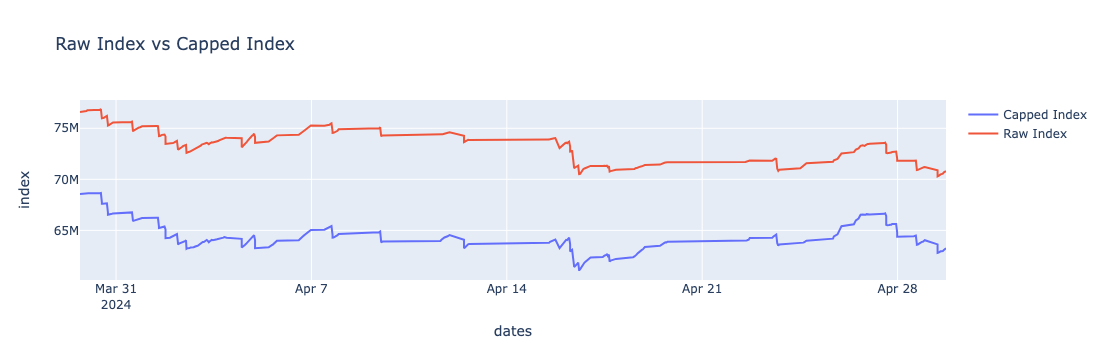

In [28]:
ind, ind_data = most_traded_index(
        df=agg_df,
        n=5000,
        quantity_measure='min_quantity',
        raw_index=raw_index,
        compare=False,
        min_quantity=5,
        plot=False
    )
ind_data = get_index_share(ind_data)
mapping = pd.read_csv('mapping.csv', index_col=0)
# Limit data to after mapping learning date
ind_data = ind_data[ind_data['Datetime'] > '2024-03-29']
ind_data = ind_data.merge(mapping, on='Watch_Mark', how='inner')
# map_df = get_caps(ind_data, upper_multiplier=1, lower_multiplier=1)
map_df = get_caps_k(ind_data)
# # capped_ind, _,_,_ = cap_index(map_df)
capped_ind = cap_index(map_df, max_iter=400)
capped_ind['index'] = capped_ind['index'].ewm(span=150, adjust=False).mean() # we can change the span value
ind['index'] = ind['index'].ewm(span=150, adjust=False).mean() # we can change the span value
plot_inds(ind, capped_ind, 'Raw Index', 'Capped Index')

In [29]:
# Small items
item_list_small = ['MINT Rolex Submariner Date Stainless Steel BLACK Ceramic 40mm 116610 LN Watch',
             '40mm Steel & 18ct Yellow Gold Oyster 16613 1991',
             '40mm Black Two-Tone 18K Gold NO-HOLES Steel Watch 16613',
             '16803 black dial steel yellow gold'
]

# Big items
item_list_big = ['Stainless Steel Yellow Gold Blue Dial 116613LB',
             '116659SABR White Gold Blue Dial Sapphire Diamond Bezel (2019)',
             'Yellow Gold Blue Dial 116618LB',
             'White Gold Submariner Diamond Sapphire Watch Ref. 116659SABR'
             ]

def item_list_top(n):
    return mapping.sort_values('avg_index_share', ascending=False).iloc[:n,0].tolist()

def item_list_bottom(n):
    return mapping.sort_values('avg_index_share', ascending=True).iloc[:n,0].tolist()


In [30]:
capped_ind.rename(columns={'DateTime': 'Datetime'}, inplace=True)

In [ ]:
ind, ind_data = most_traded_index(
    df=agg_df,
    n=5000,
    quantity_measure='min_quantity',
    raw_index=raw_index,
    compare=False,
    min_quantity=5,
    plot=False
)
ind_data = get_index_share(ind_data)
mapping = pd.read_csv('mapping.csv', index_col=0)
ind_data = ind_data[ind_data['Datetime'] > '2024-03-29']
ind_data = ind_data.merge(mapping, on='Watch_Mark', how='inner')
map_df = get_caps_k(ind_data)
attacked_df = simulate_attack(map_df, item_list_top(3), 17, increase=True)
attacked_df = get_index_share(attacked_df)
att_capped_ind = cap_index(attacked_df, max_iter=400)
capped_ind = cap_index(map_df, max_iter=400)
capped_ind['index'] = capped_ind['index'].ewm(span=150, adjust=False).mean()
att_capped_ind['index'] = att_capped_ind['index'].ewm(span=150, adjust=False).mean()
plot_inds(capped_ind, att_capped_ind, 'Capped Index', 'Attacked Capped Index')

Number of products: 599
[Timestamp('2024-04-16 01:18:21'), Timestamp('2024-04-17 01:18:21'), Timestamp('2024-04-18 01:18:21'), Timestamp('2024-04-19 01:18:21'), Timestamp('2024-04-20 01:18:21'), Timestamp('2024-04-21 01:18:21'), Timestamp('2024-04-22 01:18:21'), Timestamp('2024-04-23 01:18:21'), Timestamp('2024-04-24 01:18:21'), Timestamp('2024-04-25 01:18:21'), Timestamp('2024-04-26 01:18:21'), Timestamp('2024-04-27 01:18:21'), Timestamp('2024-04-28 01:18:21'), Timestamp('2024-04-29 01:18:21'), Timestamp('2024-04-30 01:18:21'), Timestamp('2024-05-01 01:18:21'), Timestamp('2024-05-02 01:18:21')]


###### att_capped_ind.rename(columns={'DateTime': 'Datetime'}, inplace=True)

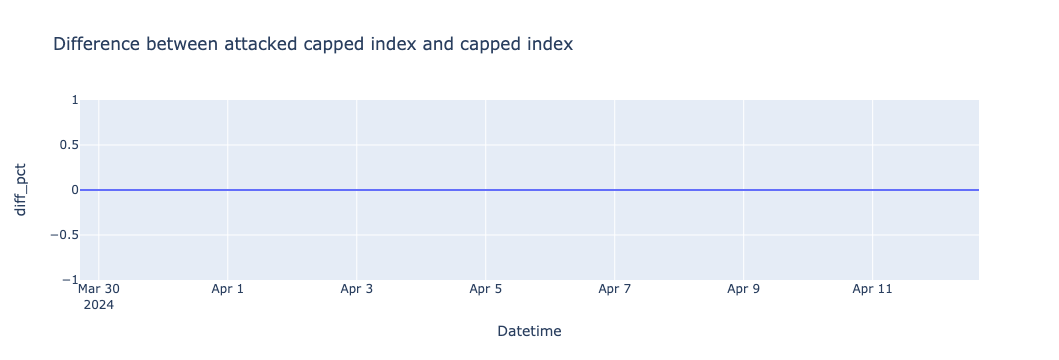

In [29]:
# Plot difference between capped_ind and att_capped_ind using plotly
diff = pd.DataFrame()
# Rename column index to att_capped_index
att_capped_ind = att_capped_ind.rename(columns={'index': 'att_capped_index'})
diff = att_capped_ind.merge(capped_ind, on='Datetime', how='inner')
diff['diff_pct'] = (diff['att_capped_index'] - diff['index']) * 100/diff['index']
px.line(diff, x='Datetime', y='diff_pct', title='Difference between attacked capped index and capped index')

In [30]:
# Only cap item list on give dates. Everything else uncapped.

ind, ind_data = most_traded_index(
    df=agg_df,
    n=5000,
    quantity_measure='min_quantity',
    raw_index=raw_index,
    compare=False,
    min_quantity=6,
    plot=False
)
ind_data = get_index_share(ind_data)
mapping = pd.read_csv('mapping.csv', index_col=0)
# Limit data to after mapping learning date
ind_data = ind_data[ind_data['Datetime'] > '2024-03-29']
ind_data = ind_data.merge(mapping, on='Watch_Mark', how='inner')
map_df = get_caps(ind_data, upper_multiplier=1, lower_multiplier=1000, items=item_list)
date_list = [map_df['Datetime'][5] + pd.Timedelta(days=i) for i in range(30)]
map_df['upper_cap_index_share'] = np.where(
    (map_df['Watch_Mark'].isin(item_list)) & (map_df['dates.date'].isin(date_list)),
    map_df['upper_cap_index_share'],
    1
)
attacked_df = simulate_attack(map_df, item_list, 30, increase=True)
attacked_df = get_index_share(attacked_df)
att_capped_ind, valid, invalid_lower, invalid_upper = cap_index(attacked_df)
plot_inds(ind, att_capped_ind, 'Capped Index', 'Attacked Capped Index')

Number of products: 439


NameError: name 'item_list' is not defined

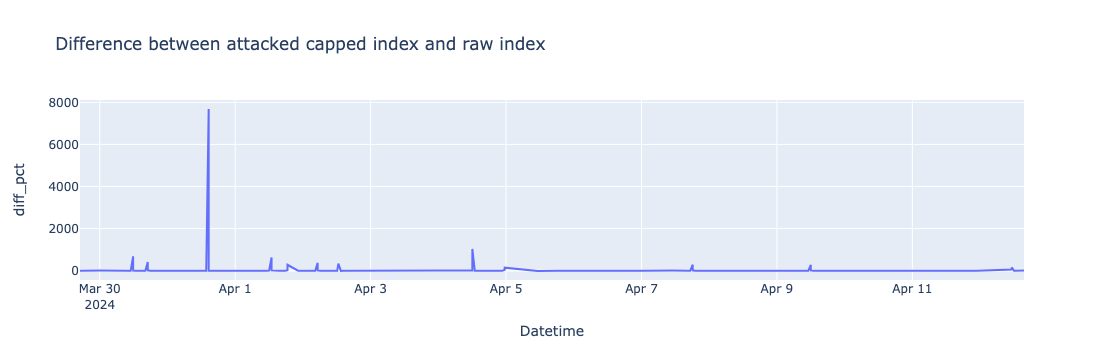

In [31]:
# Plot difference between capped_ind and att_capped_ind using plotly
diff = pd.DataFrame()
# rename column index to att_capped_index
att_capped_ind = att_capped_ind.rename(columns={'index': 'att_capped_index'})
diff = att_capped_ind.merge(ind, on='Datetime', how='inner')
diff['diff_pct'] = (diff['att_capped_index'] - diff['index']) * 100/diff['index']
px.line(diff, x='Datetime', y='diff_pct', title='Difference between attacked capped index and raw index')

In [99]:
mapping

,Watch_Name,Watch_Mark,avg_index_share,std_index_share,quantity
0,Rolex Submariner,16613 18k Yellow Gold/steel Blue Dial/bezel W/...,0.001880,0.000782,7
1,Rolex Submariner,16613 18k Yellow Gold/steel Slate Serti Dial u...,0.001498,0.000632,6
2,Rolex Submariner,16613 Submariner Blue Dial 18k Yellow Gold Men...,0.001459,0.000321,6
3,Rolex Submariner,18k Solid Yellow Gold 16618 T Blue Dial - Engr...,0.002880,0.002204,6
4,Rolex Submariner,Blue Dial Yellow Gold Oyster Bracelet 40mm 16618,0.003544,0.002719,7
...,...,...,...,...,...
418,Rolex Submariner Date,basel one Submariner Date blue dial gold steel...,0.001587,0.000517,6
419,Rolex Submariner Date,white gold blue dial ceramic submariner,0.002314,0.002368,7
420,Rolex Submariner Date,“Bluesy” 18k Yellow Gold 41mm 126618LB 2022,0.003667,0.000986,6
421,Rolex Submariner Date,“Smurf” 18k White Gold Blue Ceramic 40mm Watch...,0.004540,0.003265,8
